# Model Calibration

**Basic notebook setup: Add directories to path, import basic jax and set to 64-bit precision, set up plotting**

In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"


# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)

# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
import equinox as eqx
import dLux.utils as dlu
import jax.nn as nn
from jax import vmap
from amigo.ramp_models import RNNRamp, calc_kernels, apply_kernels_stride
from amigo.detector_models import PixelSensitivity
from amigo.optical_models import gen_powers, distort_coords


class DFRNN(eqx.Module):
    """ "Dynamic Filter Recurrent Neural Network (DFRNN) to model charge diffusion and
    bleeding."""

    kernel_model: None
    use_bias: bool
    time_steps: int = eqx.field(static=True)

    def __init__(self, key, order=2, time_steps=8, use_bias=True):
        self.kernel_model = DFN(order=order, key=key)
        self.time_steps = time_steps
        self.use_bias = use_bias

    def __call__(self, bias, illuminance, sensitivity, bleed=True):
        # Normalise by the time-steps
        illuminance /= self.time_steps

        illum = dlu.downsample(sensitivity * illuminance, 3, mean=False)
        sensitivity = dlu.downsample(sensitivity, 3, mean=True)

        # Get the initial charge
        if self.use_bias:
            charge = bias - np.mean(bias)
        else:
            charge = np.zeros_like(bias)

        # Evolve the charge
        charges, diffusions = [charge], []
        for _ in range(self.time_steps):

            if bleed:
                # Calculate the transfer kernels
                norm_charge = charge - np.mean(charge)
                kernels = self.kernel_model(norm_charge[None]).T

                # Apply the kernels
                new_charge = sensitivity * apply_kernels_stride(illuminance, kernels)
                charge += new_charge

                diffusions.append(illum - new_charge)
            else:
                new_charge = sensitivity * dlu.downsample(illuminance, 3, mean=False)
                charge += new_charge
                diffusions.append(np.zeros_like(charge))

            # Add the new charge
            charges.append(charge)

        if self.use_bias:
            ramp = np.array(charges) + np.median(bias)
        else:
            ramp = np.array(charges) + bias
        return ramp, np.array(diffusions)


class DFN(eqx.Module):
    """
    Dynamic Filter Network (DFN) to predict transposed convolution kernels
    based on charge/bias distribution.
    """

    encoder: eqx.Module  # CNN to encode charge/bias distribution
    # dense: eqx.Module  # CNN to encode charge/bias distribution
    distort_fn: callable  # Function to distort the kernels

    def __init__(self, order=3, key=None):

        # Coordinate distortion set up
        knots = dlu.pixel_coords(3, 1)
        powers = np.array(gen_powers(order))
        n_features = np.array(powers).size
        self.distort_fn = lambda coeffs: distort_coords(
            knots, coeffs.reshape(powers.shape), powers
        )

        # Default convolutional layers
        def Conv2d(in_channels=1, out_channels=1):
            return lambda key: eqx.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                key=key,
                use_bias=False,
            )

        # Convolution layers: Feature extraction from charge/bias distribution
        conv_layers = [
            Conv2d(in_channels=1, out_channels=32),
            Conv2d(in_channels=32, out_channels=32),
            Conv2d(in_channels=32, out_channels=n_features),
        ]

        # Initialize them with keys, and add relu activation
        keys = jr.split(key, len(conv_layers))
        layers = []
        for i, layer in enumerate(conv_layers):
            layers.append(layer(keys[i]))
            if i < len(conv_layers) - 1:
                layers.append(eqx.nn.Lambda(nn.relu))

        # Construct the encoder
        self.encoder = eqx.nn.Sequential(layers)

        # # Dense layer to predict the distortion coefficients
        # self.dense = eqx.nn.MLP(
        #     in_size=8,
        #     out_size=n_features,
        #     width_size=16,
        #     depth=4,
        #     activation=jax.nn.relu,
        #     use_bias=False,
        #     use_final_bias=False,
        #     key=jr.key(42),
        # )

    def __call__(self, charge_bias):
        """Predict spatially adaptive transposed convolution kernels."""

        # TODO: Try this but without adding the base coordinates back to allow for shifts?
        def distort_coords(coords, coeffs, pows):
            pow_base = np.multiply(*(coords[:, None, ...] ** pows[..., None, None]))
            distortion = np.sum(coeffs[..., None, None] * pow_base[None, ...], axis=1)
            return coords + distortion

        #
        features = self.encoder(charge_bias)
        coeffs_vec = features.reshape(len(features), -1).T

        # #
        # features_vec = self.encoder(charge_bias)
        # coeffs = vmap(self.dense)(features_vec)
        # coeffs_vec = coeffs.reshape(len(coeffs), -1).T

        #
        npix = charge_bias.shape[-1]
        coords = vmap(self.distort_fn)(1 * coeffs_vec).reshape(npix, npix, 2, 3, 3)
        kernels = calc_kernels(coords)
        return kernels


# dfnrnn_model = DFRNN(jr.key(0), order=2, time_steps=8, use_bias=True)
dfnrnn_model = DFRNN(jr.key(0))
ramp_model = RNNRamp(dfnrnn_model, gain_model=PixelSensitivity(), norm=2**14)
ramp_model.values.size

11232

In [3]:
# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    return file


def file_stats(file):
    # Get only the secondary dither position
    header = file["PRIMARY"].header
    r = np.hypot(header["XOFFSET"], header["YOFFSET"])
    im = np.array(file["SLOPE"].data, dtype=float).sum(axis=0)
    badpix = np.array(file["BADPIX"].data, dtype=float)
    im = im.at[badpix == 1].set(np.nan)
    n_photons = header["NINTS"] * np.nansum(im) / 1e6

    # Remove TD-CAL for star names
    if "TD-CAL-" in header["TARGPROP"]:
        header["TARGPROP"] = header["TARGPROP"].replace("TD-CAL-", "")
    return r, im, n_photons

In [114]:
import amigo
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")
K_path = os.path.join(cache, "K/")
fig_path = os.path.join(cache, "figs/")

state = np.load(os.path.join(model_cache, "cal_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)


files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)

exposures = [amigo.model_fits.PointFit(file) for file in files]

In [4]:
# from astropy.io import fits


# val_files = []

# print("COMM1903")
# program_path = "../../data/calslope/COMM1903"
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     r, im, n_photons = file_stats(file)

#     header = file["PRIMARY"].header
#     conds = (
#         header["IS_PSF"],
#         header["PATTTYPE"] == "NONE",
#         header["NUMDTHPT"] == 1,
#         header["TARGPROP"] == "HD-36805",
#         r > 1,
#     )

#     if all(conds):
#         val_files.append(file)
#         print(
#             header["FILTER"],
#             f"{n_photons:.0f}",
#             header["NGROUPS"],
#             f"{np.nanmax(im)/1e3:.1f}",
#             header["TARGPROP"],
#         )

# print()
# print("GO1843")
# program_path = "../../data/calslope/GO1843"
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     r, im, n_photons = file_stats(file)

#     header = file["PRIMARY"].header
#     conds = (
#         header["IS_PSF"],
#         header["PATTTYPE"] == "NONE",
#         header["NUMDTHPT"] == 1,
#     )

#     if all(conds):
#         val_files.append(file)

#         print(
#             header["FILTER"],
#             f"{n_photons:.0f}",
#             header["NGROUPS"],
#             f"{np.nanmax(im)/1e3:.1f}",
#             header["TARGPROP"],
#         )

# print()
# print("GTO1242")
# program_path = "../../data/calslope/GTO1242"
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     r, im, n_photons = file_stats(file)

#     header = file["PRIMARY"].header
#     conds = (
#         header["IS_PSF"],
#         n_photons > 1000,
#         header["FILTER"] != "F277W",
#         header["TARGPROP"] != "HD-101531",
#     )

#     if all(conds):
#         val_files.append(file)
#         print(
#             header["FILTER"],
#             f"{n_photons:.0f}",
#             header["NGROUPS"],
#             f"{np.nanmax(im)/1e3:.1f}",
#             header["TARGPROP"],
#         )

# print()
# fnames = set([f[0].header["FILENAME"] for f in val_files])
# program_path = "../../data/calslope/calibrators"
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     r, im, n_photons = file_stats(file)

#     header = file["PRIMARY"].header
#     conds = (
#         header["IS_PSF"],
#         n_photons > 1000,
#         header["FILTER"] not in ["F277W"],
#         header["FILENAME"] not in fnames,
#         header["TARGPROP"] in ["HD-116084"],
#     )

#     if all(conds):
#         val_files.append(file)
#         print(
#             header["FILTER"],
#             f"{n_photons:.0f}",
#             header["NGROUPS"],
#             f"{np.nanmax(im)/1e3:.1f}",
#             header["TARGPROP"],
#         )


# len(val_files)

In [5]:
# # from astropy.io import fits
# # from amigo.model_fits import FlatFit
# # from scripts.load_files import cal_files, val_files, flat_files


# program_path = "../../data/calslope/CAL04481"

# cal_files = []
# for fname in os.listdir(program_path):
#     if "DS_Store" in fname:
#         continue
#     file_path = os.path.join(program_path, fname)
#     file = add_badpix(fits.open(file_path))
#     cal_files.append(file)
#     r, im, n_photons = file_stats(file)

#     print(
#         header["FILTER"],
#         f"{n_photons/1e6:.0f}",
#         header["NGROUPS"],
#         f"{np.nanmax(im)/1e3:.1f}",
#     )


# len(cal_files)

In [6]:
# from amigo.files import get_files

# # Get the field files
# data_path = "../../data/calslope"
# flat_files = [add_badpix(f) for f in get_files(f"{data_path}/flats/", "nis_calslope")]

# _flat_files = []
# for file in flat_files:
#     if file[0].header["NGROUPS"] == 45:
#         print("Skipping")
#         continue
#     _flat_files.append(file)
# flat_files = _flat_files

In [7]:
# bp = np.load("../../amigo/src/amigo/data/badpix.npy")

# #
# badpix = np.zeros((80, 80))
# for file in flat_files:
#     badpix = np.array(file["BADPIX"].data)
#     badpix += badpix.astype(int)

# #
# badpix = ~(badpix == 0)
# full_badpix = badpix | bp


# def add_bpix(file):
#     badpix = np.array(file["BADPIX"].data, dtype=bool)
#     file["BADPIX"].data = (badpix | full_badpix).astype(int)
#     return file

In [8]:
# file.info()

In [9]:
# from amigo.model_fits import PointFit, FlatFit

# # Construct the exposures
# flat_exposures = [FlatFit(add_bpix(file)) for file in flat_files]
# cal_exposures = [PointFit(add_bpix(file)) for file in cal_files]
# val_exposures = [PointFit(add_bpix(file)) for file in val_files]
# exposures = cal_exposures + flat_exposures + val_exposures


# files = cal_files + val_files + flat_files
# [f.close() for f in files];

In [94]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import SUB80Detector
from amigo.read_models import ReadModel
from jax import tree as jtu


# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=True),
    detector=SUB80Detector(ramp_model=ramp_model),
    read=ReadModel(),
)

In [95]:
for key, value in state.items():
    if key == "aberrations":
        model = model.set("aberrations", jtu.map(lambda x: value, model.aberrations))
    else:
        model = model.set(key, value)

In [96]:
import matplotlib.patches as patches


def make_box(cen, length, **kwargs):
    return patches.Rectangle(
        (cen[0] - length / 2, cen[1] - length / 2),
        length,
        length,
        linewidth=2,
        facecolor="none",
        **kwargs
        # edgecolor=f"tab:{c}",
        # alpha=alpha,
    )


def kernels_to_array(oversampled_array):
    npix, _, n, _ = oversampled_array.shape
    return oversampled_array.transpose(0, 2, 1, 3).reshape(npix * n, npix * n)


def array_to_kernels(full_res_array, npix, n):
    return full_res_array.reshape(npix, n, npix, n).transpose(0, 2, 1, 3)

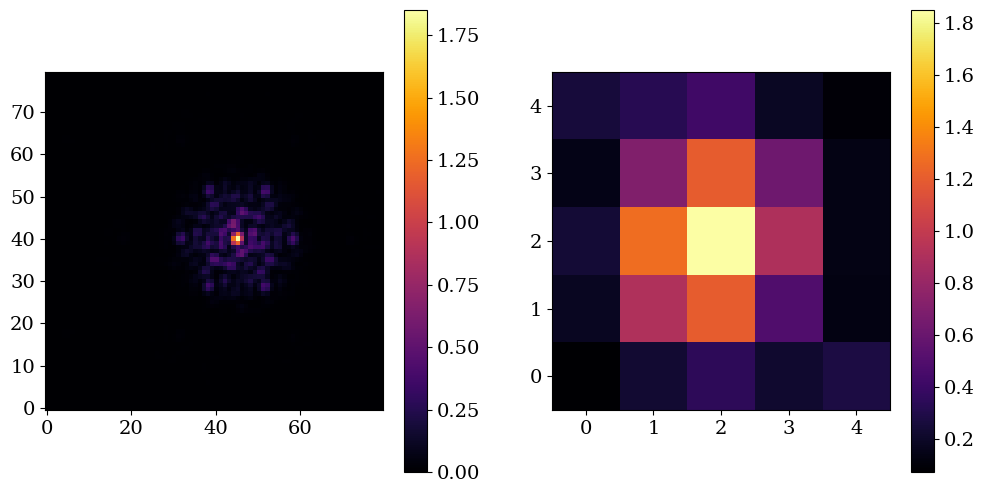

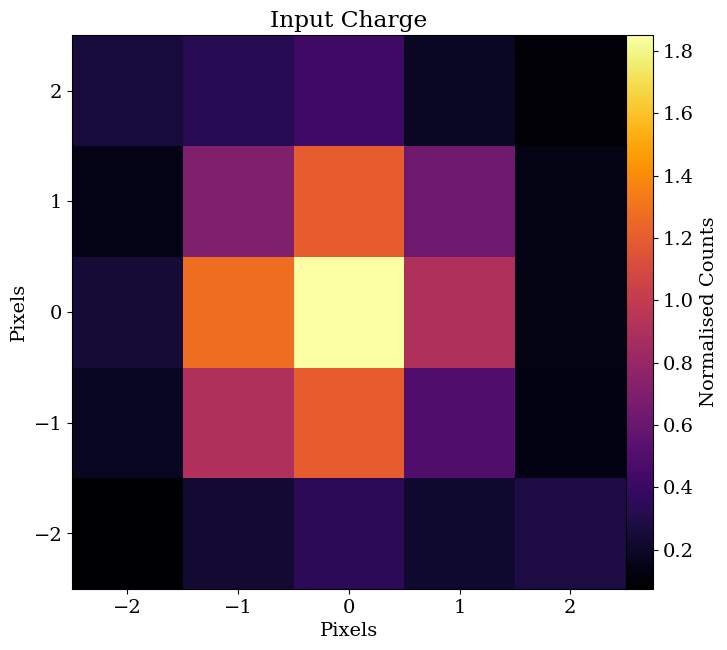

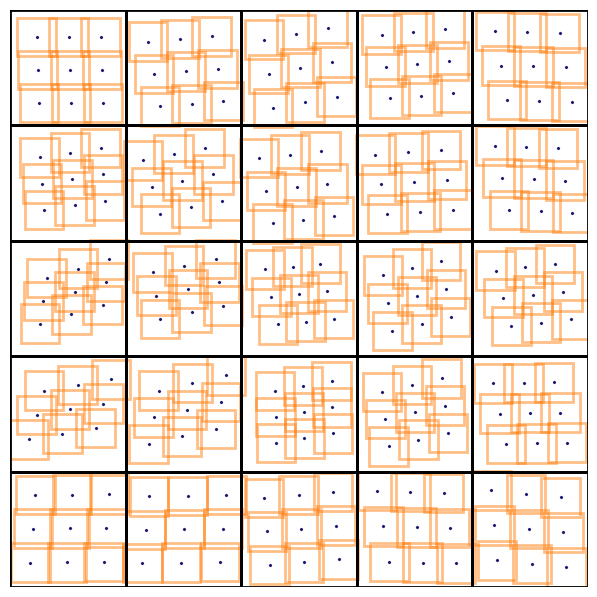

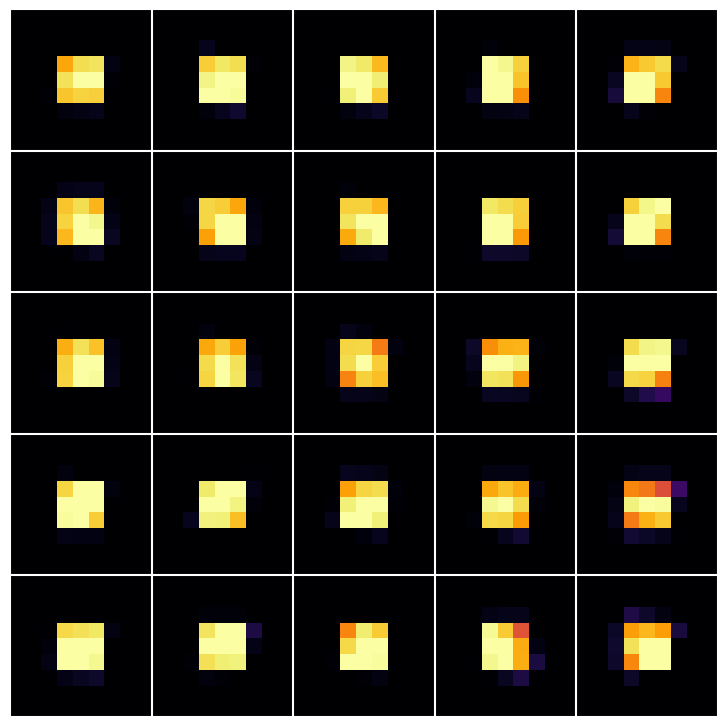

In [115]:
for exp in exposures:
    if exp.calibrator and exp.dither == 1:
        break


params = model.params
params["positions"][exp.get_key("positions")] = np.array([0.35, -0.03])
params["fluxes"][exp.get_key("fluxes")] = 5.5
model = model.set("params", params)

# Generate Charge
psf = exp.model_psf(model)
illum = exp.model_illuminance(psf, model).data
charge = dlu.downsample(illum, 3, mean=False) / model.ramp.norm

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(charge)
plt.colorbar()

# Generate Kernels
DFRNN = model.ramp.build
kernels = DFRNN.kernel_model(2 * charge[None]).T

# Generate Coordinates
npix = charge.shape[-1]
features = DFRNN.kernel_model.encoder(charge[None])
coeffs_vec = features.reshape(len(features), -1).T
coords = vmap(DFRNN.kernel_model.distort_fn)(1 * coeffs_vec).reshape(
    npix, npix, 2, 3, 3
)

# Select the region of interest
extent = (-2.5, 2.5, -2.5, 2.5)
charge = charge[38:43, 43:48]
kernel_im = kernels_to_array(kernels[..., 38:43, 43:48].T)
coords = coords[38:43, 43:48]

plt.subplot(122)
plt.imshow(charge)
plt.colorbar()
plt.show()

# Plot
# fig = plt.figure(figsize=(22.5, 7.5))

# ax = fig.add_subplot(1, 3, 1)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
im = ax.imshow(charge, extent=extent)
fig.colorbar(im, cax=merge_cbar(ax), label="Normalised Counts")
ax.set(title="Input Charge", xlabel="Pixels", ylabel="Pixels")
# plt.savefig(fig_path + "distortions.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 7.5))
# ax = fig.add_subplot(1, 3, 2)
cens = dlu.pixel_coords(5, 5)
true_coords = coords + cens.T[..., None, None]
full_coords = vmap(kernels_to_array, 2)(true_coords)
full_coords_vec = full_coords.reshape(2, -1).T
cens_vec = cens.reshape(2, -1).T

#
ax.set_aspect("equal", adjustable="box")
ax.scatter(*full_coords_vec.T, c="midnightblue", s=2, marker="x")

for cen in full_coords_vec:
    ax.add_patch(make_box(cen, 1 / 3, edgecolor="tab:orange", alpha=0.5))

for cen in cens_vec:
    ax.add_patch(make_box(cen, 1, edgecolor="k"))

plt.axis("off")

ax.set(
    # title="Pixel Distortions",
    xlabel="Pixels",
    ylabel="Pixels",
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
)
plt.savefig(fig_path + "distortions.png", dpi=300, bbox_inches="tight")
plt.show()
# ax = fig.add_subplot(1, 3, 3)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
im = ax.imshow(kernel_im, extent=extent, norm=mpl.colors.TwoSlopeNorm(0.7))
grid = np.linspace(-2.5, 2.5, 6)
for line in grid:
    ax.axvline(line, color="w")
    ax.axhline(line, color="w")

# fig.colorbar(im, cax=merge_cbar(ax), label="Kernel Weight")
plt.axis("off")
# ax.set(title="Dynamic Kernels", xlabel="Pixels", ylabel="Pixels")


plt.tight_layout()
plt.savefig(fig_path + "kernels.png", dpi=300, bbox_inches="tight")
plt.show()